<h1 align=center style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
شمارش سکه ها
</font>
</h1>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این تمرین، فرآیندهای پیش‌پردازش بر روی تصاویری از سکه ها انجام می‌گیرد. این مراحل شامل:
<br>
۱- بارگذاری تصویر
<br>
۲- باینری سازی تصویر
<br>
۳- پیش پردازش تصویر و استفاده از تکنیکهای مورفولوژی
<br>
۴- شمارش سکه ها به کمک تکنیک کانتور یابی
</font>
</p>

---

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
وارد کردن کتابخانه‌های مورد نیاز
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این بخش کتابخانه‌های مورد نیاز برای انجام تمرین را وارد می‌کنیم.
</font>
</p>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
بارگذاری داده‌ها
</font>
</h2>
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
لطفا تصویر اول از داده هایی که در اختیار شما قرار گرفته است را بصورت رنگی بخوانید و سپس با اجرای سلول، آن را نمایش دهید.
</font>
</p>

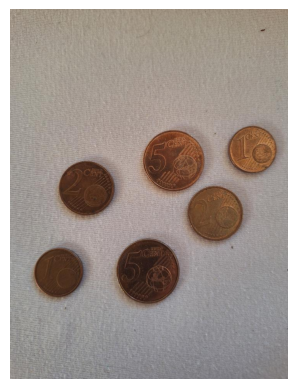

In [41]:
# read the Image1.jpg
img1 = cv2.imread("../Data/Image2.jpg")
plt.imshow(cv2.cvtColor(img1,cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
باینری سازی تصویر
</font>
</h2>
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
تصویر خوانده شده را ابتدا به سطح خاکستری تبدیل کنید و سپس آن را به کمک متد utso که پیش تر فراگرفته اید، باینری کنید. 
</font>
</p>

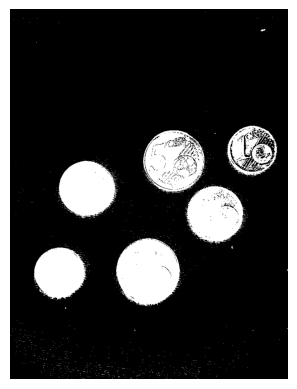

In [42]:
# Convert to grayscale
gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
# Apply Otsu's thresholding
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

plt.imshow(binary, cmap='gray')
plt.axis('off')
plt.show()

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
پیش پردازش تصویر
</font>
</h2>
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در تصویر رسم شده سلول قبل، مقداری نویز در اطراف تصویر قابل مشاهده است، یکی از راه های برطرف کردن این نوع نویزها استفاده از عملیات مورفولوژیک نظیر فرسایش (Erosion) است.
لطفا در سلول زیر با کرنل تعریف شده تنها یک بار فرسایش را روی تصویر اعمال کنید.
</font>
</p>

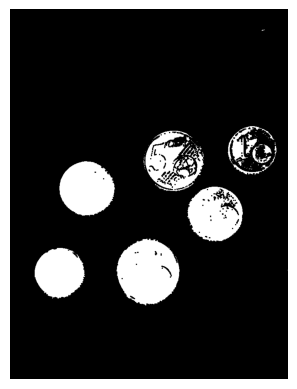

In [45]:
kernel = np.ones((3, 3), np.uint8)
# Apply Erosion technique to remove noise
eroded = cv2.erode(binary, kernel, iterations=1)


plt.imshow(eroded, cmap='gray')
plt.axis('off')
plt.show()

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
ادامه پیش پردازش تصویر
</font>
</h2>
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
نویز ها حذف شدند اما به دلیل یکسان نبودن نورپردازی تصویر و انجام عملیات فرسایش، پس از باینری سازی تصویر مشاهده میشود درون سکه ها به صورت کامل پر نشده است که این اتفاق باعث میشود نتوان به خوبی عملیات شمارش سکه ها را انجام داد بنابراین با استفاده از عملیات گسترش، سعی میکنیم درون سکه ها را پر کنیم. در سلول زیر روی تصویر فرسایش یافته (eroded) عملیات گسترش (dilation) را انجام دهید. 
</font>
</p>

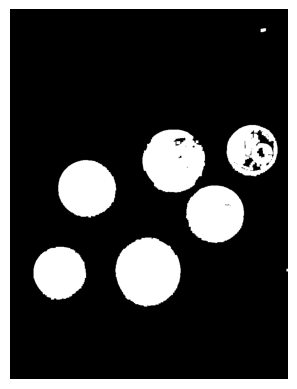

In [ ]:
kernel = np.ones((3, 3), np.uint8)
# Apply Dilation technique to fill coins
# Apply Dilation on `eroded` variable and make sure the iterations been 3 times
dilated = cv2.dilate(eroded, kernel, iterations=3)


plt.imshow(dilated, cmap='gray')
plt.axis('off')
plt.show()

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
شمارش سکه ها
</font>
</h2>
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
پس از پایان عملیات پیش پردازش حال نوبت انجام عملیات اصلی یعنی شمارش سکه هاست. این کار را به کمک کانتوریابی انجام میدهیم. در ادامه فصل مورفولوژی بیشتر با این عملیات آشنا خواهیم شد و درسنامه آن را مطالعه خواهید کرد.

کانتور در واقع مرزهای خارجی تصویر می‌باشد. یعنی منحنی‌های پیوسته‌ای هستند که مرز کامل یک جسم را پوشش می‌دهند.ه رچه الگوریتم های پردازش تصویر در زمینه یافتن کانتور تصویر دقیق‌تر باشند این منحنی بسته به لبه‌های خارجی اشیا در تصویر نزدیک‌تر هست. 

از آنجا که خیلی با مبحث کانتورها آشنایی ندارید کد این قسمت بصورت آماده در سلول زیر آماده است فقط این را بدانید. از آنجا که هنوز ممکن است سکه ها بطور کامل پر نشده باشند متد پیدا کردن کانتور را طوری تعریف کرده ایم که برای عملیات کانتوریابی مرز خارجی اشیا را در نظر بگیرد.
</font>
</p>

In [51]:
# Find contours (only external ones)
contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter contours by area to remove noise (we only select those contours which their area is more than 4000)
min_area = 4000  # Adjust this based on your coin size
filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]

print ('Number of Coins: ', len(filtered_contours))


Number of Coins:  6


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
!ببینیم چیشد
</font>
</h2>
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
برای اینکه ببینیم چگونه به نتیجه درست رسیدیم، سلول زیر را اجرا کنید. در واقع با روش کانتورینگ سعی کردیم، کانتورهایی که مساحت آنها از 4000 بیشتر بود را فیلتر کنیم و نمایش دهیم که این اتفاق باعث شد سکه ها پیدا شوند. 
</font>
</p>

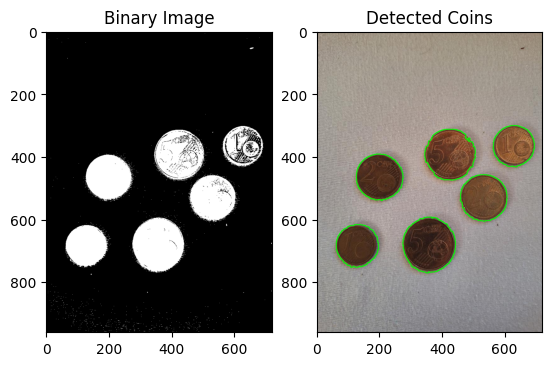

In [52]:
contour_image = img1.copy()
cv2.drawContours(contour_image, filtered_contours, -1, (0, 255, 0), 2)  # Outline
# cv2.drawContours(contour_image, filtered_contours, -1, (0, 255, 0), thickness=cv2.FILLED)  # Fill

# Show results
plt.subplot(1, 2, 1)
plt.imshow(binary, cmap='gray')
plt.title('Binary Image')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(contour_image, cv2.COLOR_BGR2RGB))
plt.title('Detected Coins')

plt.show()


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
!تابعش کنیم
</font>
</h2>
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
لطفا قسمت های مهم سلول های قبل یعنی باینری سازی، فرسایش و گسترش و پیدا کردن کانتور ها را در تابع زیر پیاده سازی کنید تا تصویر در ورودی دریافت کرده و تعداد سکه های موجود در تصویر را برگرداند.
</font>
</p>

In [58]:
def coin_counter(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, binary = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    kernel = np.ones((3, 3), np.uint8)
    eroded = cv2.erode(binary, kernel, iterations=1)
    dilated = cv2.dilate(eroded, kernel, iterations=3)

    contours, _ = cv2.findContours(
        dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    filtered = [c for c in contours if cv2.contourArea(c) > 4000]
    return len(filtered)


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
تست تابع
</font>
</h2>
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
تصویر دوم موجود در داده های اولیه را به خورد تابعی که نوشتید بدهید و ببینید خروجی تابع صحیح هست یا خیر.
</font>
</p>

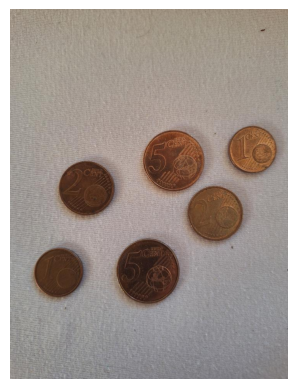

6


In [59]:
img2 = cv2.imread("../Data/Image2.jpg")
plt.imshow(cv2.cvtColor(img2,cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()
num_coins = coin_counter(img2)
print(num_coins)

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
<b>سلول جواب‌ساز</b>
</font>
</h2>


<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
    برای ساخته‌شدن فایل <code>result.zip</code> سلول زیر را اجرا کنید. توجه داشته باشید که پیش از اجرای سلول زیر تغییرات اعمال شده در نت‌بوک را ذخیره کرده باشید (<code>ctrl+s</code>) تا در صورت نیاز به پشتیبانی امکان بررسی کد شما وجود داشته باشد.
</font>
</p>

In [60]:
import zipfile
from inspect import getsource

def compress(file_names):
    print("File Paths:")
    print(file_names)
    compression = zipfile.ZIP_DEFLATED
    with zipfile.ZipFile("result.zip", mode="w") as zf:
        for file_name in file_names:
            zf.write('./' + file_name, file_name, compress_type=compression)

imp = """
import cv2
import numpy as np
"""

%save coin_counter imp + getsource(coin_counter)


file_names = ["coin_counter.py", "notebook.ipynb"]
compress(file_names)

The following commands were written to file `coin_counter.py`:

import cv2
import numpy as np
def coin_counter(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, binary = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    kernel = np.ones((3, 3), np.uint8)
    eroded = cv2.erode(binary, kernel, iterations=1)
    dilated = cv2.dilate(eroded, kernel, iterations=3)

    contours, _ = cv2.findContours(
        dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    filtered = [c for c in contours if cv2.contourArea(c) > 4000]
    return len(filtered)

File Paths:
['coin_counter.py', 'notebook.ipynb']
